In [3]:
import os

train_dir = './fruit-object-detection/train'
val_dir = './fruit-object-detection/valid'

valid_extensions = ['.jpg', '.jpeg', '.png']
count_train = 0
count_val = 0

def count_images_in_directory(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if any(file.endswith(ext) for ext in valid_extensions):
                count += 1
    return count

# Count images in the training directory
count_train = count_images_in_directory(train_dir)
# Count images in the validation directory
count_val = count_images_in_directory(val_dir)
# Print the counts
print(f"Number of images in training directory: {count_train}")
print(f"Number of images in validation directory: {count_val}")
print(f"Total number of images: {count_train + count_val}")

Number of images in training directory: 3845
Number of images in validation directory: 640
Total number of images: 4485


In [1]:
import os
import shutil
import random
from pathlib import Path

# Đường dẫn gốc
src_dir = Path("fruit-object-detection")
dst_dir = Path("fruit_object_detection")

# Tạo thư mục mới với cấu trúc train, validation, test
for split in ["train", "validation", "test"]:
    (dst_dir / split / "images").mkdir(parents=True, exist_ok=True)
    (dst_dir / split / "labels").mkdir(parents=True, exist_ok=True)

# Chuyển valid → test
for ftype in ["images", "labels"]:
    src_path = src_dir / "valid" / ftype
    dst_path = dst_dir / "test" / ftype
    for file in src_path.iterdir():
        shutil.copy(file, dst_path / file.name)

# Lấy danh sách ảnh từ train/images
train_images = list((src_dir / "train" / "images").glob("*.jpg"))
random.shuffle(train_images)

# Tính số lượng validation (20%)
val_size = int(0.2 * len(train_images))
val_images = train_images[:val_size]
train_images_new = train_images[val_size:]

def copy_image_and_label(image_paths, target_split):
    for img_path in image_paths:
        label_path = src_dir / "train" / "labels" / (img_path.stem + ".txt")
        # Copy ảnh
        shutil.copy(img_path, dst_dir / target_split / "images" / img_path.name)
        # Copy label nếu tồn tại
        if label_path.exists():
            shutil.copy(label_path, dst_dir / target_split / "labels" / label_path.name)

# Copy dữ liệu đã chia vào thư mục đích
copy_image_and_label(train_images_new, "train")
copy_image_and_label(val_images, "validation")

print("✅ Đã hoàn tất chia và tạo thư mục mới.")

✅ Đã hoàn tất chia và tạo thư mục mới.


In [2]:
# Hàm đếm ảnh trong thư mục
def count_images_in_split(split):
    image_count = len(list((dst_dir / split / "images").glob("*.jpg")))
    return image_count

# In số lượng ảnh từng tập
train_count = count_images_in_split("train")
val_count = count_images_in_split("validation")
test_count = count_images_in_split("test")
total = train_count + val_count + test_count

print("📊 Thống kê số lượng ảnh:")
print(f"  🟢 Train: {train_count}")
print(f"  🔵 Validation: {val_count}")
print(f"  🟠 Test: {test_count}")
print(f"  📦 Tổng cộng: {total}")

📊 Thống kê số lượng ảnh:
  🟢 Train: 3076
  🔵 Validation: 769
  🟠 Test: 640
  📦 Tổng cộng: 4485


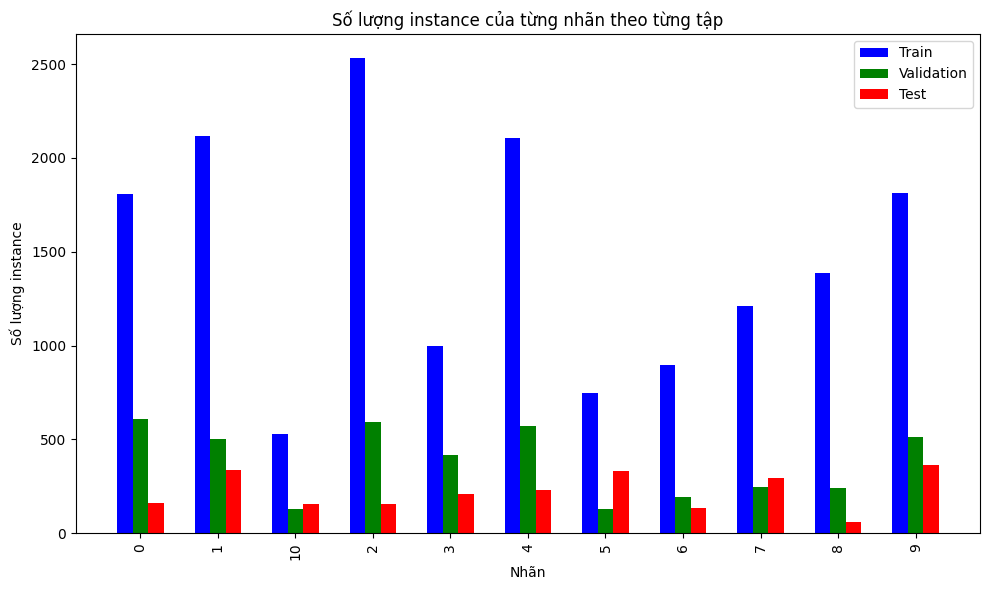

In [2]:
import matplotlib.pyplot as plt
import os
from pathlib import Path
from collections import defaultdict

# Đường dẫn đến thư mục "fruit_object_detection"
dst_dir = Path("fruit_object_detection")

# Hàm đếm số lượng instance của từng nhãn trong các tập
def count_images_and_labels_in_split(split):
    label_count_in_split = defaultdict(int)
    label_dir = dst_dir / split / "labels"
    for label_file in label_dir.iterdir():
        with open(label_file, 'r') as f:
            labels_in_image = [line.split()[0] for line in f.readlines()]
            for label in labels_in_image:
                label_count_in_split[label] += 1
    return label_count_in_split

# Đếm số lượng instance của từng nhãn trong các tập
train_label_count = count_images_and_labels_in_split("train")
val_label_count = count_images_and_labels_in_split("validation")
test_label_count = count_images_and_labels_in_split("test")

# Tạo danh sách nhãn
labels = sorted(set(train_label_count.keys()) | set(val_label_count.keys()) | set(test_label_count.keys()))

# Tạo các danh sách số lượng nhãn cho từng tập
train_counts = [train_label_count.get(label, 0) for label in labels]
val_counts = [val_label_count.get(label, 0) for label in labels]
test_counts = [test_label_count.get(label, 0) for label in labels]

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
index = range(len(labels))

ax.bar(index, train_counts, bar_width, label='Train', color='b')
ax.bar([i + bar_width for i in index], val_counts, bar_width, label='Validation', color='g')
ax.bar([i + 2 * bar_width for i in index], test_counts, bar_width, label='Test', color='r')

# Thiết lập các nhãn và tiêu đề
ax.set_xlabel('Nhãn')
ax.set_ylabel('Số lượng instance')
ax.set_title('Số lượng instance của từng nhãn theo từng tập')
ax.set_xticks([i + bar_width for i in index])
ax.set_xticklabels(labels)
ax.legend()

# Hiển thị biểu đồ
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [4]:
import os
import json
import time
import random
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

from tqdm.auto import tqdm

In [5]:
# Thiết lập device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

# Định nghĩa tên các lớp
CLASS_NAMES = [
    "apple", "tangerine", "pear", "watermelon", "durian",
    "lemon", "grape", "pineapple", "dragon fruit", "korean melon", "cantaloupe"
]
NUM_ACTUAL_CLASSES = len(CLASS_NAMES)
NUM_MODEL_CLASSES = NUM_ACTUAL_CLASSES + 1 # Bao gồm cả background

# Đường dẫn cơ sở
BASE_DATA_DIR = './fruit_object_detection' # Thay đổi nếu cần
ANNOTATIONS_DIR = os.path.join(BASE_DATA_DIR, 'annotations')

Using device: cuda


In [6]:
# Đường dẫn file annotations
TRAIN_ANNOTATIONS_FILE = os.path.join(ANNOTATIONS_DIR, "train_annotations.json")
VAL_ANNOTATIONS_FILE = os.path.join(ANNOTATIONS_DIR, "validation_annotations.json")
TEST_ANNOTATIONS_FILE = os.path.join(ANNOTATIONS_DIR, "test_annotations.json")

# Đường dẫn thư mục ảnh
TRAIN_IMG_DIR = os.path.join(BASE_DATA_DIR, "train", "images")
VAL_IMG_DIR = os.path.join(BASE_DATA_DIR, "validation", "images")
TEST_IMG_DIR = os.path.join(BASE_DATA_DIR, "test", "images")

In [7]:
class FruitDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        """
        Custom Dataset cho fruit object detection
        
        Args:
            annotations_file (str): Đường dẫn đến file COCO json annotations
            img_dir (str): Thư mục chứa ảnh
            transform (callable, optional): Transform để áp dụng lên ảnh và bboxes
        """
        self.img_dir = img_dir
        self.transform = transform
        
        if not os.path.exists(annotations_file):
            raise FileNotFoundError(f"Annotation file not found: {annotations_file}")
        if not os.path.exists(img_dir):
            raise NotADirectoryError(f"Image directory not found: {img_dir}")
            
        self.coco = COCO(annotations_file)
        self.ids = list(sorted(self.coco.imgs.keys())) # Lấy image ids
        
        # Lấy danh sách categories từ file JSON (id: 0-10)
        self.coco_categories = self.coco.loadCats(self.coco.getCatIds())
        self.coco_cat_id_to_name = {cat["id"]: cat["name"] for cat in self.coco_categories}
        
        print(f"Loaded {len(self.ids)} images from {annotations_file}.")
        # print(f"COCO Categories (from JSON): {self.coco_cat_id_to_name}")

    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        annotations = self.coco.loadAnns(ann_ids)
        
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        
        boxes = []
        labels = []
        areas = []
        iscrowd = []
        
        for ann in annotations:
            # COCO format: [x_min, y_min, width, height]
            # Chuyển sang [x1, y1, x2, y2] cho PyTorch
            x_min, y_min, width, height = ann['bbox']
            x1 = x_min
            y1 = y_min
            x2 = x_min + width
            y2 = y_min + height
            
            boxes.append([x1, y1, x2, y2])
            # QUAN TRỌNG: category_id từ file JSON (0-10) được +1 để thành nhãn cho model (1-11)
            # Model sẽ coi nhãn 0 là background.
            labels.append(ann['category_id'] + 1) 
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        # Chuyển đổi sang tensor
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        else: # Trường hợp không có object nào trong ảnh
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
            areas = torch.zeros(0, dtype=torch.float32)
            iscrowd = torch.zeros(0, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": areas,
            "iscrowd": iscrowd
        }
        
        if self.transform:
            image, target = self.transform(image, target)
        
        return image, target

In [8]:
class Compose:
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

class ToTensor:
    def __call__(self, image, target):
        image = F.to_tensor(image)
        return image, target

class RandomHorizontalFlip:
    def __init__(self, prob=0.5):
        self.prob = prob
    def __call__(self, image, target):
        if random.random() < self.prob:
            height, width = image.shape[-2:]
            image = image.flip(-1)
            bbox = target["boxes"]
            if bbox.shape[0] > 0: # Chỉ flip nếu có box
                 bbox[:, [0, 2]] = width - bbox[:, [2, 0]]
                 target["boxes"] = bbox
        return image, target

def get_transform(train):
    transforms = [ToTensor()]
    if train:
        transforms.append(RandomHorizontalFlip(0.5))
    return Compose(transforms)

def collate_fn(batch):
    return tuple(zip(*batch))

# Tạo datasets
print("\nĐang tạo datasets...")
train_dataset = FruitDataset(TRAIN_ANNOTATIONS_FILE, TRAIN_IMG_DIR, transform=get_transform(train=True))
val_dataset = FruitDataset(VAL_ANNOTATIONS_FILE, VAL_IMG_DIR, transform=get_transform(train=False))
test_dataset = FruitDataset(TEST_ANNOTATIONS_FILE, TEST_IMG_DIR, transform=get_transform(train=False))
print("Hoàn tất tạo datasets.")

# Tạo DataLoaders
BATCH_SIZE = 4 # Giảm nếu gặp lỗi Out of Memory (OOM)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
print(f"Số lượng batch trong train_loader: {len(train_loader)}")
print(f"Số lượng batch trong val_loader: {len(val_loader)}")
print(f"Số lượng batch trong test_loader: {len(test_loader)}")


Đang tạo datasets...
loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Loaded 3076 images from ./fruit_object_detection\annotations\train_annotations.json.
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Loaded 769 images from ./fruit_object_detection\annotations\validation_annotations.json.
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loaded 640 images from ./fruit_object_detection\annotations\test_annotations.json.
Hoàn tất tạo datasets.
Số lượng batch trong train_loader: 769
Số lượng batch trong val_loader: 193
Số lượng batch trong test_loader: 160



--- Mẫu ảnh từ tập Train ---


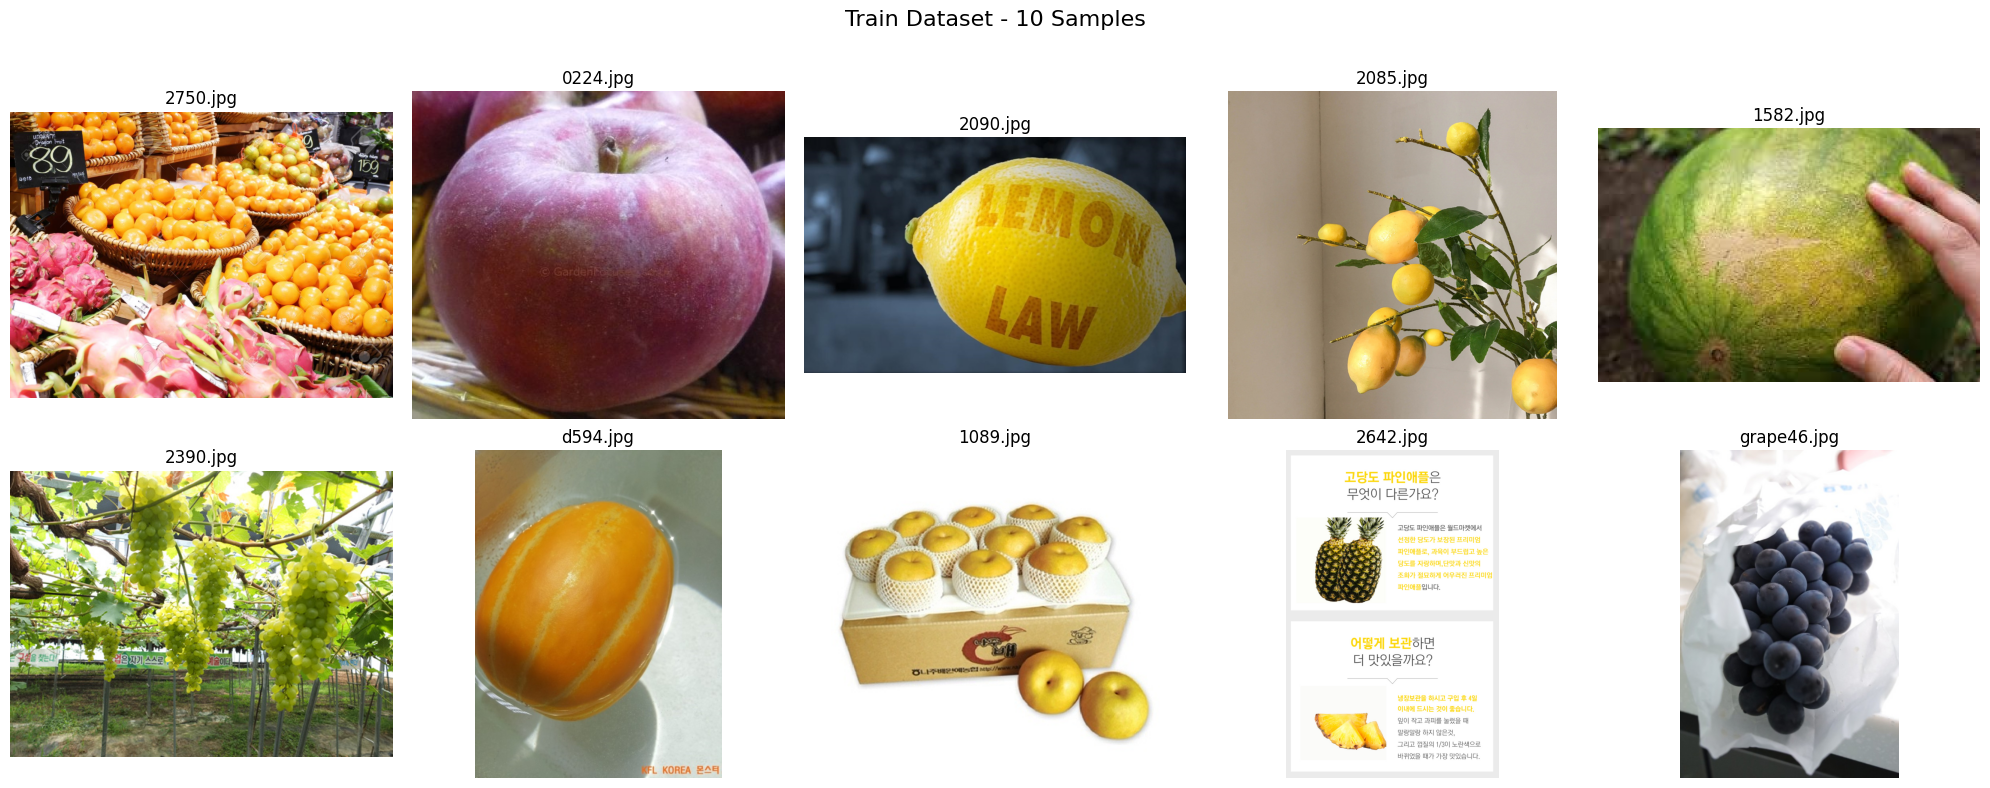


--- Mẫu ảnh từ tập Validation ---


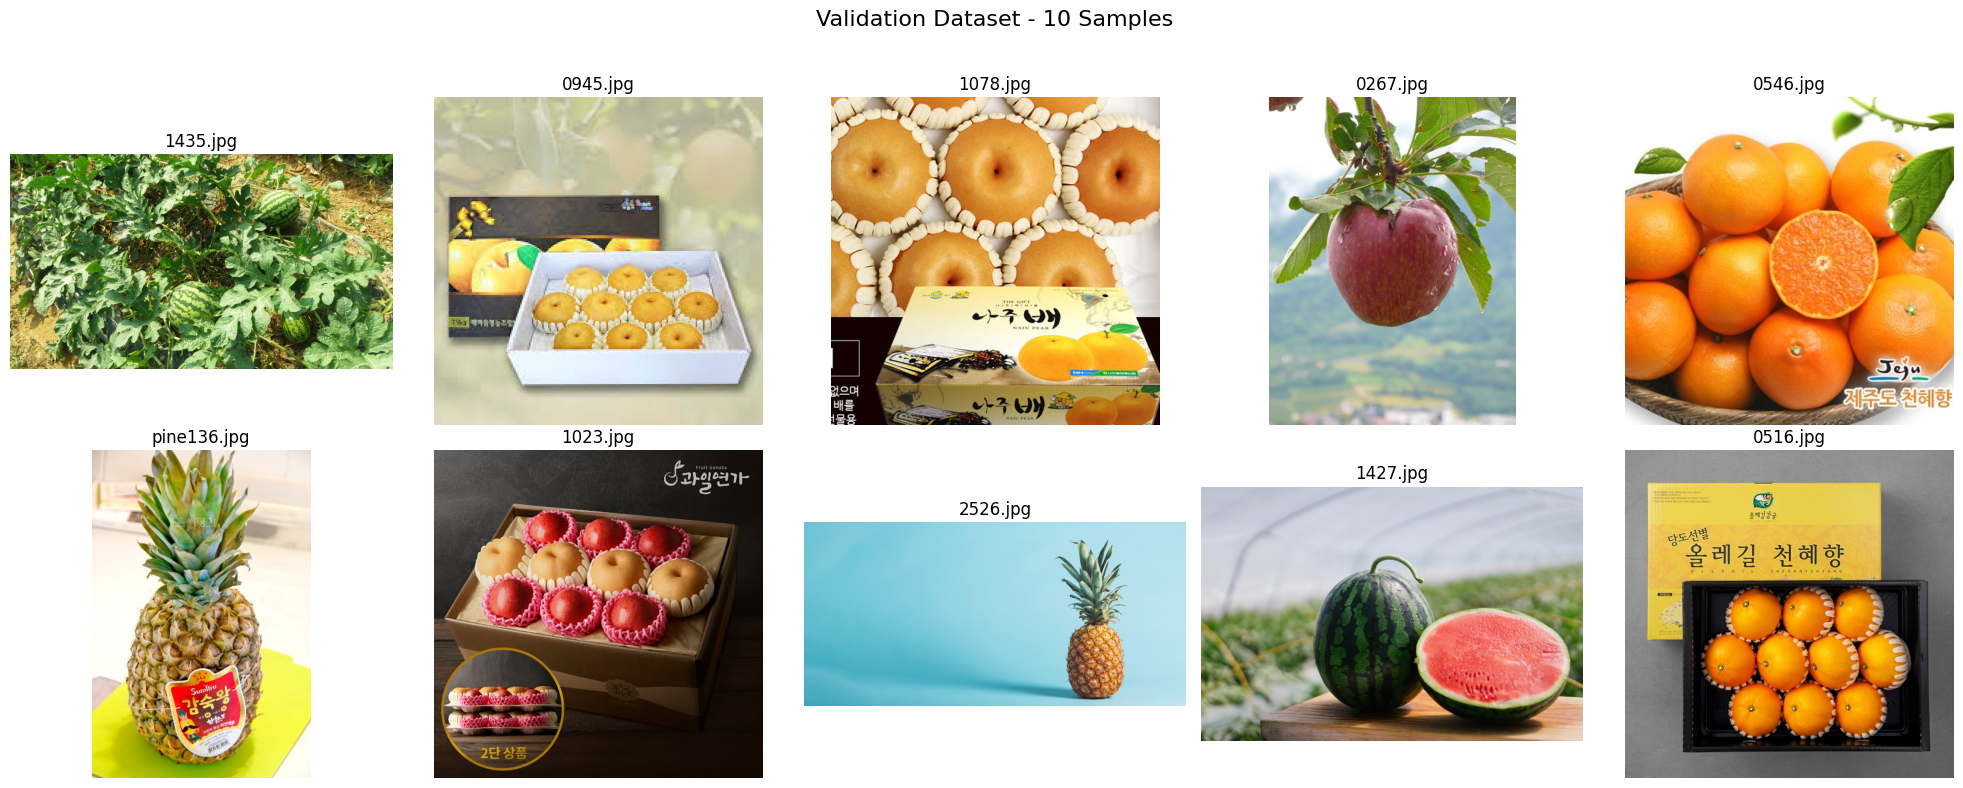


--- Mẫu ảnh từ tập Test ---


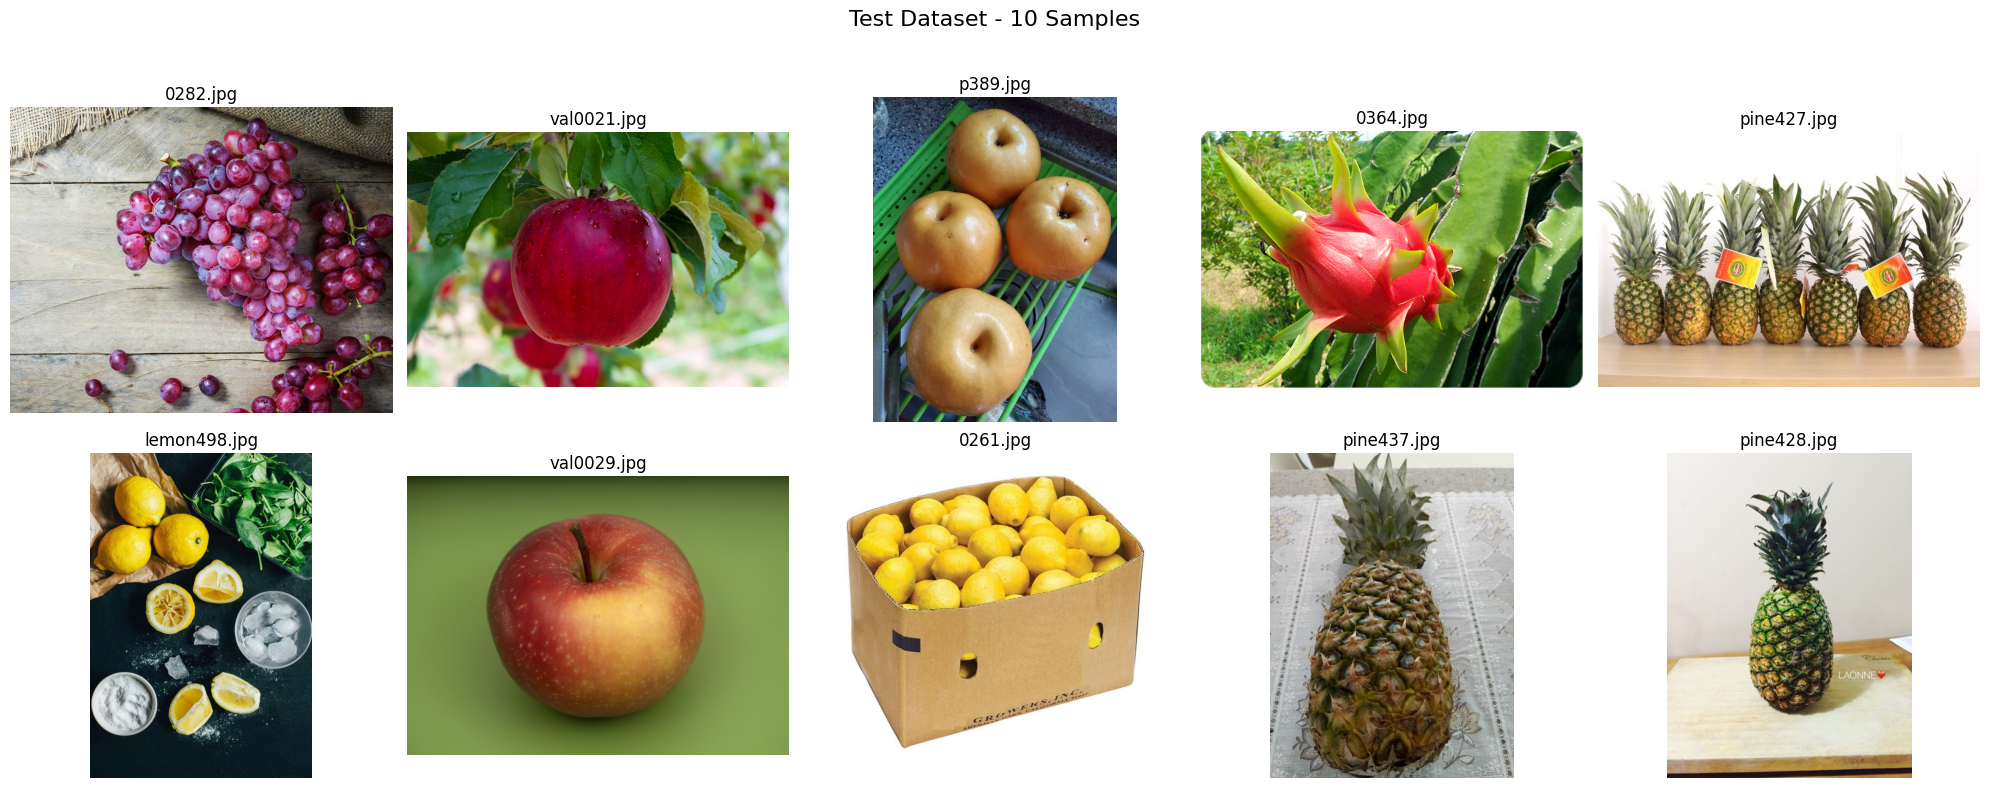

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os # Đảm bảo os được import

# Giả định rằng bạn đã có các đối tượng Dataset:
# train_dataset, val_dataset, test_dataset
# Và logging đã được cấu hình (nếu bạn muốn dùng logging)

def visualize_image_samples(dataset, num_samples=5, title_prefix="Sample Images"):
    """
    Trực quan hóa một số lượng ảnh ngẫu nhiên từ dataset.

    Args:
        dataset (torch.utils.data.Dataset): Đối tượng Dataset đã được khởi tạo.
                                           Hàm này giả định dataset có thuộc tính:
                                           - ids: list các image_id (như trong FruitDataset)
                                           - coco: đối tượng COCO API (như trong FruitDataset)
                                           - img_dir: đường dẫn đến thư mục chứa ảnh
        num_samples (int): Số lượng ảnh muốn hiển thị.
        title_prefix (str): Tiền tố cho tiêu đề của biểu đồ.
    """
    if not hasattr(dataset, 'ids') or not hasattr(dataset, 'coco') or not hasattr(dataset, 'img_dir'):
        message = f"Dataset cung cấp cho {title_prefix} không có các thuộc tính cần thiết (ids, coco, img_dir)."
        print(message)
        # logging.error(message) # Nếu bạn dùng logging
        return

    if len(dataset.ids) == 0: # Kiểm tra qua dataset.ids
        message = f"Dataset rỗng, không có ảnh để hiển thị cho {title_prefix}."
        print(message)
        # logging.warning(message) # Nếu bạn dùng logging
        return

    # Lấy các index ngẫu nhiên từ dataset
    actual_num_samples = min(num_samples, len(dataset.ids))
    sample_indices = random.sample(range(len(dataset.ids)), actual_num_samples)

    # Tạo subplot để hiển thị các ảnh
    cols = min(actual_num_samples, 5) # Hiển thị tối đa 5 ảnh trên một hàng
    rows = (actual_num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows)) # Giảm kích thước một chút
    if actual_num_samples == 1:
        axes = [axes] # Đưa vào list để có thể lặp
    axes = axes.flatten()

    for i, data_idx in enumerate(sample_indices): # data_idx là index trong dataset.ids
        ax = axes[i]
        
        coco_img_id = dataset.ids[data_idx]
        img_info = dataset.coco.loadImgs(coco_img_id)[0]
        img_path = os.path.join(dataset.img_dir, img_info['file_name'])
        
        try:
            image_pil = Image.open(img_path).convert("RGB")
            ax.imshow(image_pil)
            ax.set_title(f"{img_info['file_name']}")
        except Exception as e:
            # logging.error(f"Lỗi khi mở ảnh {img_path} để trực quan hóa: {e}") # Nếu bạn dùng logging
            print(f"Lỗi khi mở ảnh {img_path} để trực quan hóa: {e}")
            ax.set_title(f"Lỗi tải ảnh:\n{img_info['file_name']}", fontsize=8)
        
        ax.axis('off') # Tắt trục tọa độ

    # Ẩn các subplot không sử dụng
    for j in range(actual_num_samples, rows * cols):
        fig.delaxes(axes[j])
        
    plt.suptitle(f"{title_prefix} - {actual_num_samples} Samples", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- CÁCH SỬ DỤNG ---
# Giả định train_dataset, val_dataset, test_dataset đã được khởi tạo
# và chúng là instance của FruitDataset (hoặc một class tương tự có .ids, .coco, .img_dir)

# Trực quan hóa tập train
# logging.info("Trực quan hóa một vài mẫu ảnh từ tập Train:") # Nếu bạn dùng logging
print("\n--- Mẫu ảnh từ tập Train ---")
if 'train_dataset' in globals() and train_dataset is not None and hasattr(train_dataset, 'ids') and len(train_dataset.ids) > 0:
   visualize_image_samples(train_dataset, num_samples=10, title_prefix="Train Dataset")
else:
   print("Train dataset không được định nghĩa hoặc rỗng.")
   # logging.info("Train dataset không được định nghĩa hoặc rỗng, bỏ qua trực quan hóa.")

# Trực quan hóa tập validation
# logging.info("Trực quan hóa một vài mẫu ảnh từ tập Validation:") # Nếu bạn dùng logging
print("\n--- Mẫu ảnh từ tập Validation ---")
if 'val_dataset' in globals() and val_dataset is not None and hasattr(val_dataset, 'ids') and len(val_dataset.ids) > 0:
   visualize_image_samples(val_dataset, num_samples=10, title_prefix="Validation Dataset")
else:
   print("Validation dataset không được định nghĩa hoặc rỗng.")
   # logging.info("Validation dataset không được định nghĩa hoặc rỗng, bỏ qua trực quan hóa.")


# logging.info("Trực quan hóa một vài mẫu ảnh từ tập Test:") # Nếu bạn dùng logging
print("\n--- Mẫu ảnh từ tập Test ---")
if 'test_dataset' in globals() and test_dataset is not None and hasattr(test_dataset, 'ids') and len(test_dataset.ids) > 0:
   visualize_image_samples(test_dataset, num_samples=10, title_prefix="Test Dataset")
else:
   print("Test dataset không được định nghĩa hoặc rỗng.")
   # logging.info("Test dataset không được định nghĩa hoặc rỗng, bỏ qua trực quan hóa.")